# Train MobileNetV2 (GitHub repo) on your dataset

Pick one of these official PyTorch repos and train **the actual MobileNetV2** end‑to‑end on your images:

- **d-li14/mobilenetv2.pytorch** (training script & multiple width multipliers)  
- **tonylins/pytorch-mobilenet-v2** (clean MobileNetV2 module)

**Dataset expected:**
```
model/datasets/
  train/{fresh,not_fresh}/{species}/*.jpg
  validation/{fresh,not_fresh}/{species}/*.jpg
  test/{fresh,not_fresh}/{species}/*.jpg   # optional
```

We flatten `(freshness, species)` into one label like `fresh__bigeye_scad` so we can use the standard ImageNet training code.

## 0) Choose repo (`REPO`): `'dli14'` or `'tonylins'`

In [5]:
REPO = 'dli14'  # <-- change to 'tonylins' if you prefer that implementation
EPOCHS = 40     # try 120–150 later for best accuracy
LR = 0.05
BATCH = 32
INPUT_SIZE = 224
NUM_WORKERS = 0

## 1) Install PyTorch (skip if already installed)

In [3]:
import sys, subprocess
def pipi(args):
    print('> pip', ' '.join(args))
    subprocess.check_call([sys.executable, '-m', 'pip'] + args)
try:
    import torch, torchvision
    print('Torch/Torchvision already installed')
except Exception as e:
    print('Installing PyTorch CUDA 11.8 wheels...')
    pipi(['install','torch','torchvision','torchaudio','--index-url','https://download.pytorch.org/whl/cu118'])

Torch/Torchvision already installed


## 2) Clone the chosen repo

In [6]:
import subprocess, os
if REPO == 'dli14':
    url = 'https://github.com/d-li14/mobilenetv2.pytorch.git'
    target = 'mobilenetv2.pytorch'
elif REPO == 'tonylins':
    url = 'https://github.com/tonylins/pytorch-mobilenet-v2.git'
    target = 'pytorch-mobilenet-v2'
else:
    raise ValueError("REPO must be 'dli14' or 'tonylins'")

if not os.path.exists(target):
    subprocess.check_call(['git', 'clone', url])
else:
    print('Repo already cloned:', target)

## 3) Deduper using Perceptual Hash (pHash)

In [9]:
# === IMAGE DEDUPLICATION (pHash / histogram / embedding) ===
# Works with your layout: model/datasets/{train,validation,test}/{fresh,not_fresh}/{species}/*.jpg

import os, shutil, math, json
from pathlib import Path
from collections import defaultdict

# --------- CONFIG ---------
ROOT = Path("datasets/")         # where your raw split folders live
SPLITS = ["train","validation","test"] # which splits to scan
GROUP_MODE = "class"  # "class" -> dedupe within each (freshness/species) across all splits,
                      # "split" -> dedupe inside each split separately,
                      # "global" -> dedupe across all images together (be careful)
METHOD = "phash"      # "phash" (default), "hist", "embed"
DRY_RUN = False        # True -> only report; False -> move/delete duplicates
ACTION = "move"       # "move" -> move dups to ROOT/_duplicates/...,  "delete" -> remove them
# thresholds
PHASH_HAMMING = 5     # 0..64  (lower = stricter)
HIST_SIM = 0.995      # cosine similarity threshold (0..1, higher = stricter)
EMBED_SIM = 0.996     # cosine similarity threshold for CNN embeddings

OUT = Path("model/models") if Path("model").exists() else Path("models")
OUT.mkdir(parents=True, exist_ok=True)
REPORT = OUT/"duplicates.csv"
DUPS_DIR = ROOT/"_duplicates"

# --------- UTILS ---------
def list_images(root: Path):
    exts = {".jpg",".jpeg",".png",".bmp",".webp"}
    for p in root.rglob("*"):
        if p.suffix.lower() in exts:
            yield p

def group_key(p: Path):
    # Expect: .../<split>/<fresh|not_fresh>/<species>/image.jpg
    parts = p.parts
    if GROUP_MODE == "global":
        return "ALL"
    if GROUP_MODE == "split":
        # group by split/freshness/species folder path
        # find split index
        for s in SPLITS:
            if s in parts:
                i = parts.index(s)
                return "/".join(parts[i:i+3]) if len(parts) >= i+3 else "/".join(parts[i:])
        return "unknown"
    # default: class (freshness/species) across *all* splits
    # find freshness + species no matter which split
    for s in SPLITS:
        if s in parts:
            i = parts.index(s)
            if len(parts) >= i+3:
                return "/".join(parts[i+1:i+3])  # e.g. 'fresh/bigeye_scad'
    return "unknown"

def prefer_keep(a: Path, b: Path):
    # Keep order: train > validation > test, then shorter filename
    rank = { "train":0, "validation":1, "test":2 }
    def key(p: Path):
        sp = next((s for s in SPLITS if s in p.parts), "zzz")
        return (rank.get(sp, 9), len(p.name))
    return a if key(a) <= key(b) else b

def ensure_deps():
    import importlib, sys, subprocess, os
    def pip_install(*pkgs):
        # short temp/cache paths help on Windows
        Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
        os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
        subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir",*pkgs])
    # PIL
    try: import PIL  # noqa
    except: pip_install("Pillow")
    if METHOD == "phash":
        try: import imagehash  # noqa
        except: pip_install("imagehash")
    if METHOD == "embed":
        try:
            import torch, torchvision  # noqa
        except:
            pip_install("torch","torchvision","torchaudio","--index-url","https://download.pytorch.org/whl/cpu")

ensure_deps()

# --------- SIMILARITY BACKENDS ---------
from PIL import Image, UnidentifiedImageError
import numpy as np

def cosine(a, b, eps=1e-8):
    return float(np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + eps))

def sim_phash(paths):
    import imagehash
    hashes = []
    for p in paths:
        try:
            with Image.open(p) as im:
                h = imagehash.phash(im.convert("RGB"))  # 64-bit
            hashes.append(int(str(h), 16))
        except Exception:
            hashes.append(None)
    # O(n^2) grouping
    n = len(paths); used=set(); groups=[]
    for i in range(n):
        if hashes[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if hashes[j] is None or j in used: continue
            # hamming distance between two 64-bit ints
            d = (hashes[i] ^ hashes[j]).bit_count()
            if d <= PHASH_HAMMING:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))  # score optional
    return groups

def sim_hist(paths):
    def histvec(p):
        try:
            with Image.open(p) as im:
                hsv = im.convert("HSV")
                h,s,v = hsv.split()
                h1,_ = np.histogram(np.array(h).ravel(), bins=32, range=(0,255))
                s1,_ = np.histogram(np.array(s).ravel(), bins=32, range=(0,255))
                v1,_ = np.histogram(np.array(v).ravel(), bins=32, range=(0,255))
                vec = np.concatenate([h1,s1,v1]).astype(np.float32)
                vec /= (np.linalg.norm(vec)+1e-8)
                return vec
        except Exception:
            return None
    vecs = [histvec(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= HIST_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

def sim_embed(paths):
    import torch, torchvision
    from torchvision import transforms
    # MobileNetV2 backbone -> 1280-d embedding
    weights = torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
    net = torchvision.models.mobilenet_v2(weights=weights)
    net.classifier = torch.nn.Identity()
    net.eval()
    tfm = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                              transforms.ToTensor(), transforms.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])])
    def emb(p):
        try:
            with Image.open(p) as im:
                x = tfm(im.convert("RGB")).unsqueeze(0)
            with torch.no_grad():
                e = net(x).squeeze(0).numpy().astype(np.float32)
            e /= (np.linalg.norm(e)+1e-8)
            return e
        except Exception:
            return None
    vecs = [emb(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= EMBED_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

METHOD_FN = {"phash": sim_phash, "hist": sim_hist, "embed": sim_embed}[METHOD]

# --------- SCAN & GROUP ---------
# Build class groups (freshness/species) across all splits
buckets = defaultdict(list)
for split in SPLITS:
    base = ROOT/split
    if not base.exists(): continue
    for p in list_images(base):
        buckets[group_key(p)].append(p)

total_imgs = sum(len(v) for v in buckets.values())
print(f"Scanning {len(buckets)} groups with {total_imgs} images using method='{METHOD}'")

# --------- FIND DUPLICATES & REPORT ---------
rows = [["group","keeper","duplicate","method","note"]]
dups = []
for gname, files in buckets.items():
    if len(files) < 2: continue
    # stable order: prefer keep train > validation > test
    files = sorted(files, key=lambda p: (["train","validation","test"].index(next((s for s in SPLITS if s in p.parts), "test")) if any(s in p.parts for s in SPLITS) else 9, p.name))
    groups = METHOD_FN(files)
    for idxs, _ in groups:
        # Decide keeper inside the group (by priority)
        keeper = files[idxs[0]]
        for j in idxs[1:]:
            dup = files[j]
            dups.append((gname, keeper, dup))

# Save report
for g, keep, dup in dups:
    rows.append([g, str(keep), str(dup), METHOD, ""])
REPORT.write_text("\n".join([",".join(map(str,r)) for r in rows]), encoding="utf-8")
print(f"Found {len(dups)} duplicates. Report -> {REPORT.resolve()}")

# --------- ACT ON DUPLICATES ---------
if DRY_RUN or not dups:
    print("DRY_RUN=True (no files moved/deleted). Set DRY_RUN=False to apply.")
else:
    DUPS_DIR.mkdir(parents=True, exist_ok=True)
    for g, keep, dup in dups:
        if ACTION == "delete":
            try: dup.unlink()
            except Exception as e: print("fail delete:", dup, e)
        else:
            # move to _duplicates, mirroring relative path
            rel = dup.relative_to(ROOT)
            dest = DUPS_DIR/rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            try: shutil.move(str(dup), str(dest))
            except Exception as e: print("fail move:", dup, "->", dest, e)
    print(f"Applied ACTION='{ACTION}'. Duplicates moved to {DUPS_DIR} (or deleted).")


Scanning 10 groups with 834 images using method='phash'
Found 22 duplicates. Report -> E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model\models\duplicates.csv
Applied ACTION='move'. Duplicates moved to datasets\_duplicates (or deleted).


## 4) Draws distribution bar charts of dataset

[skip] missing split: datasets\testing
Saved counts -> E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model\models\dataset_counts.csv
Loaded duplicate removals from: E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model\models\duplicates.csv


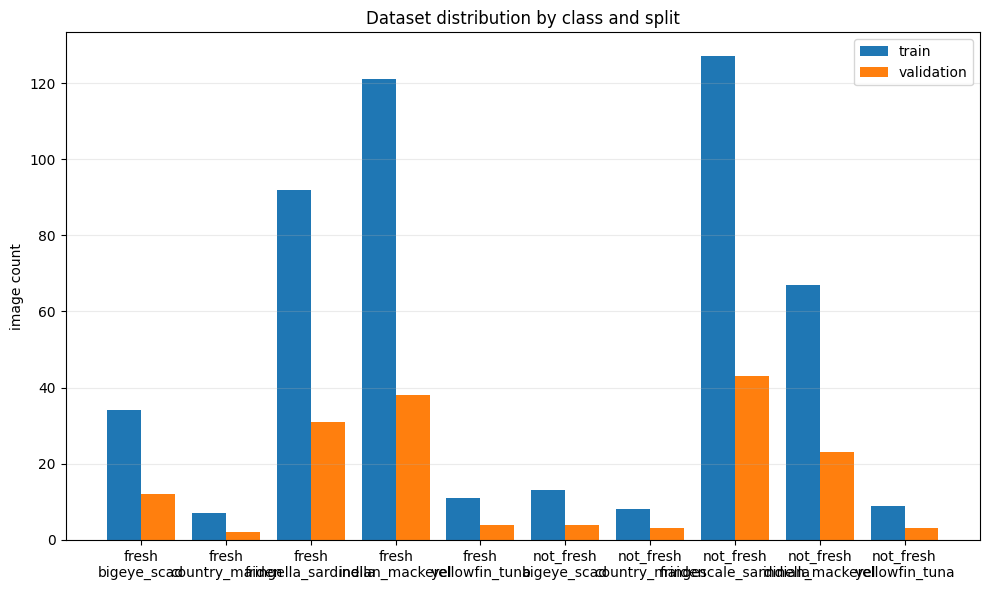

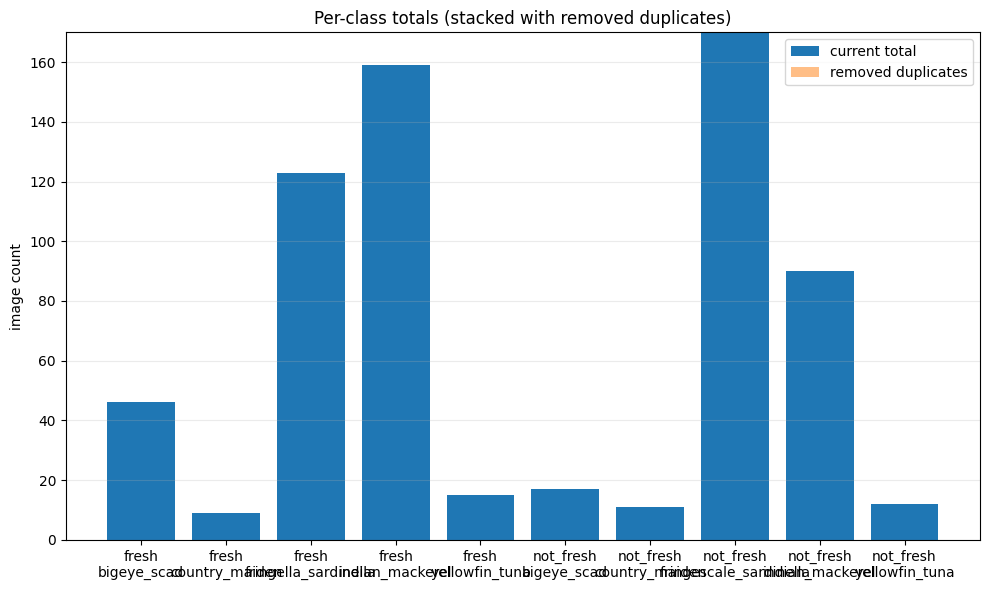

In [2]:
# === CLEANED DATASET DISTRIBUTION CHARTS ===
# Works with: datasets/{train,validation,testing}/{fresh|not_fresh}/{species}/*.jpg
from pathlib import Path
import os, sys, subprocess

# --- CONFIG (adjust if needed) ---
ROOT   = Path("datasets")                   # you're running inside model/
SPLITS = ["train","validation","testing"]   # use your split names
SAVE_DIR = Path("models") if Path("models").exists() else Path("model/models")

# --- ensure deps ---
try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas","numpy"])
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

# --- count images per class & split ---
EXTS = {".jpg",".jpeg",".png",".bmp",".webp"}
rows = []
for split in SPLITS:
    base = ROOT/split
    if not base.exists():
        print(f"[skip] missing split: {base}")
        continue
    for freshness in ["fresh","not_fresh"]:
        fdir = base/freshness
        if not fdir.exists():
            continue
        for species_dir in sorted([p for p in fdir.iterdir() if p.is_dir()]):
            n = sum(1 for p in species_dir.rglob("*") if p.suffix.lower() in EXTS)
            rows.append({"class": f"{freshness}__{species_dir.name}", "split": split, "count": n})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("No images found. Check ROOT/SPLITS and your folder structure.")

wide = (df.pivot_table(index="class", columns="split", values="count", aggfunc="sum")
          .fillna(0).astype(int)
          .sort_index())

SAVE_DIR.mkdir(parents=True, exist_ok=True)
(wide.to_csv(SAVE_DIR/"dataset_counts.csv"))
print("Saved counts ->", (SAVE_DIR/"dataset_counts.csv").resolve())

# --- optional: duplicates removed (if report exists) ---
dup_csv = SAVE_DIR/"duplicates.csv"
dup_counts = None
if dup_csv.exists():
    try:
        ddf = pd.read_csv(dup_csv)
        if "group" in ddf.columns:
            dup_counts = ddf.groupby("group").size().rename("removed").to_frame()
            dup_counts.index.name = "class"
            print("Loaded duplicate removals from:", dup_csv.resolve())
    except Exception as e:
        print("Could not read duplicates.csv:", e)

# --- grouped bar chart: per split ---
classes = wide.index.tolist()
present_splits = [s for s in SPLITS if s in wide.columns]
n_classes = len(classes)
n_splits = max(1, len(present_splits))
x = np.arange(n_classes)
bar_w = 0.8 / n_splits

plt.figure(figsize=(max(10, n_classes*0.55), 6))
for k, split in enumerate(present_splits):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    plt.bar(xs, wide[split].values, width=bar_w, label=split)
plt.xticks(x, [c.replace("__","\n") for c in classes])
plt.ylabel("image count")
plt.title("Dataset distribution by class and split")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# --- totals (+ optional stacked 'removed duplicates') ---
totals = wide.sum(axis=1).rename("total")
plt.figure(figsize=(max(10, n_classes*0.55), 6))
plt.bar(x, totals.values, label="current total")
if dup_counts is not None:
    rem = dup_counts.reindex(totals.index).fillna(0)["removed"].values
    plt.bar(x, rem, bottom=totals.values, label="removed duplicates", alpha=0.5)
plt.xticks(x, [c.replace("__","\n") for c in totals.index])
plt.ylabel("image count")
plt.title("Per-class totals" + (" (stacked with removed duplicates)" if dup_counts is not None else ""))
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 5) (Datasets Splitting) Flatten dataset to ImageFolder layout

In [ ]:
# 3) Flatten dataset to ImageFolder (robust paths)
from pathlib import Path
import shutil, json

# ---- Auto-detect where the 'model/' folder is relative to this notebook ----
if Path('model/datasets/train').exists():
    MODEL_DIR = Path('model')
elif Path('datasets/train').exists():           # notebook opened inside model/
    MODEL_DIR = Path('.')
else:
    # last resort: search upwards
    cand = [p.parent for p in Path.cwd().rglob('datasets/train')]
    if cand:
        MODEL_DIR = cand[0]
    else:
        raise SystemExit("Couldn't find 'datasets/train'. Open the notebook in your project root or set MODEL_DIR manually.")

print("MODEL_DIR ->", MODEL_DIR.resolve())

SRC = MODEL_DIR / 'datasets'                    # expects train/, validation/, (test/)
DST = MODEL_DIR / 'pytorch_imagenet'            # will create train/, val/, test/
DST.mkdir(parents=True, exist_ok=True)

def flatten_split(split_name, out_name):
    src = SRC / split_name
    out = DST / out_name
    if not src.exists():
        print(f"[skip] {src} not found")
        return False
    out.mkdir(parents=True, exist_ok=True)
    copied = 0
    for freshness in ['fresh', 'not_fresh']:
        base = src / freshness
        if not base.exists():
            print(f"[warn] missing {base}")
            continue
        for sp_dir in base.iterdir():
            if not sp_dir.is_dir(): 
                continue
            cls = f"{freshness}__{sp_dir.name}"
            out_cls = out / cls
            out_cls.mkdir(parents=True, exist_ok=True)
            for img in sp_dir.rglob('*'):
                if img.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}:
                    shutil.copy2(img, out_cls / img.name)
                    copied += 1
    print(f"[done] {split_name} -> {out}  (copied {copied} files)")
    return copied > 0

ok_train = flatten_split('train', 'train')
ok_val   = flatten_split('validation', 'val')
ok_test  = flatten_split('test', 'test')

if not ok_train:
    raise SystemExit("No training images were copied. Check your source layout: "
                     "model/datasets/train/{fresh,not_fresh}/{species}/*.jpg")

# Build class list
train_dir = DST / 'train'
CLASSES = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASSES)
(MODEL_DIR/'models').mkdir(parents=True, exist_ok=True)
(MODEL_DIR/'models'/'classes.json').write_text(json.dumps(CLASSES, indent=2))
print(f"Classes ({NUM_CLASSES}):", CLASSES[:20], "...")
print("Wrote:", (MODEL_DIR/'models'/'classes.json').resolve())


MODEL_DIR -> E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model
[done] train -> pytorch_imagenet\train  (copied 489 files)
[done] validation -> pytorch_imagenet\val  (copied 163 files)
[done] test -> pytorch_imagenet\test  (copied 160 files)
Classes (10): ['fresh__bigeye_scad', 'fresh__country_maiden', 'fresh__fringella_sardinella', 'fresh__indian_mackerel', 'fresh__yellowfin_tuna', 'not_fresh__bigeye_scad', 'not_fresh__country_maiden', 'not_fresh__fringescale_sardinella', 'not_fresh__indian_mackerel', 'not_fresh__yellowfin_tuna'] ...
Wrote: E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model\models\classes.json


## 6) (Augmentation) Dataloaders & transforms

In [6]:
# === DATALOADERS (robust; sets defaults if missing) ===
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ---- defaults if not already defined above ----
INPUT_SIZE  = int(globals().get('INPUT_SIZE', 224))
BATCH       = int(globals().get('BATCH', 16))
NUM_WORKERS = int(globals().get('NUM_WORKERS', 0))  # Windows CPU: keep 0
# ------------------------------------------------------

# Find the flattened dataset root created by your "flatten" step
if Path('model/pytorch_imagenet/train').exists():
    DST = Path('model/pytorch_imagenet')
elif Path('pytorch_imagenet/train').exists():
    DST = Path('pytorch_imagenet')
else:
    raise SystemExit("Couldn't find the flattened dataset. Run the flatten step first "
                     "(it creates model/pytorch_imagenet/{train,val}).")

# Use 'val' if present; fall back to 'validation' if that’s what you have
VAL_DIR = DST/'val'
if not VAL_DIR.exists():
    alt = DST/'validation'
    if alt.exists():
        VAL_DIR = alt
    else:
        raise SystemExit(f"Missing validation split at {DST/'val'} (or {alt}).")

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_tfms = transforms.Compose([
    transforms.Resize(int(INPUT_SIZE*1.15)),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

data = {
    'train': datasets.ImageFolder(DST/'train', transform=train_tfms),
    'val':   datasets.ImageFolder(VAL_DIR,     transform=val_tfms),
}
loaders = {
    'train': DataLoader(data['train'], batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False),
    'val':   DataLoader(data['val'],   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False),
}

# Define CLASSES if not already set (handy for export later)
if 'CLASSES' not in globals():
    CLASSES = data['train'].classes

print("Using dataset root:", DST.resolve())
print("Train classes:", len(CLASSES), "  Train batches:", len(loaders['train']), "  Val batches:", len(loaders['val']))
print("INPUT_SIZE:", INPUT_SIZE, " BATCH:", BATCH, " NUM_WORKERS:", NUM_WORKERS)


Using dataset root: E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model\pytorch_imagenet
Train classes: 10   Train batches: 32   Val batches: 11
INPUT_SIZE: 224  BATCH: 16  NUM_WORKERS: 0


## 5) Build model from the selected GitHub repo

In [8]:
# === BUILD MobileNetV2 (robust; uses real GitHub impl) ===
import importlib.util
from pathlib import Path
import torch, torch.nn as nn

# Defaults if not set above
REPO = str(globals().get('REPO', 'dli14')).lower()      # 'dli14' or 'tonylins'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Figure out class count
if 'NUM_CLASSES' in globals():
    NUM_CLASSES = int(NUM_CLASSES)
elif 'CLASSES' in globals():
    NUM_CLASSES = len(CLASSES)
elif 'data' in globals() and 'train' in data:
    NUM_CLASSES = len(data['train'].classes)
else:
    raise SystemExit("Can't determine NUM_CLASSES. Run the dataloaders cell first so CLASSES/data exist.")

def _load_module(py_path: Path, name: str):
    if not py_path.exists():
        raise SystemExit(f"Expected file not found: {py_path}\n"
                         f"Did you clone the repo? (git clone https://github.com/d-li14/mobilenetv2.pytorch) "
                         f"or (git clone https://github.com/tonylins/pytorch-mobilenet-v2)")
    spec = importlib.util.spec_from_file_location(name, py_path)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod

def build_mbv2(repo: str, num_classes: int):
    if repo == 'dli14':
        mod = _load_module(Path('mobilenetv2.pytorch/models/imagenet/mobilenetv2.py'), 'mbv2_dli14')
        model = mod.mobilenetv2(num_classes=num_classes)
    elif repo == 'tonylins':
        mod = _load_module(Path('pytorch-mobilenet-v2/MobileNetV2.py'), 'mbv2_tonylins')
        if hasattr(mod, 'mobilenet_v2'):
            try:
                model = mod.mobilenet_v2(num_classes=num_classes)
            except TypeError:
                # some versions ignore num_classes in ctor -> replace head manually
                model = mod.mobilenet_v2()
        else:
            model = mod.MobileNetV2(num_classes=num_classes)
        # Ensure classifier out_features == num_classes
        if hasattr(model, 'classifier'):
            if isinstance(model.classifier, nn.Sequential):
                last = model.classifier[-1]
                if isinstance(last, nn.Linear) and last.out_features != num_classes:
                    model.classifier[-1] = nn.Linear(last.in_features, num_classes)
            elif isinstance(model.classifier, nn.Linear) and model.classifier.out_features != num_classes:
                model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError("REPO must be 'dli14' or 'tonylins'")
    return model

model = build_mbv2(REPO, NUM_CLASSES).to(device)

# Print a tiny summary
head = None
if hasattr(model, 'classifier'):
    head = model.classifier[-1] if isinstance(model.classifier, nn.Sequential) else model.classifier
print(f"Built MobileNetV2 from repo='{REPO}'  -> num_classes={NUM_CLASSES}")
print("Final head:", type(head).__name__ if head else "N/A")

# (optional) sanity forward
with torch.no_grad():
    _ = model(torch.randn(1,3,224,224).to(device))
print("Sanity forward OK on", device)


Built MobileNetV2 from repo='dli14'  -> num_classes=10
Final head: Linear
Sanity forward OK on cpu


In [10]:
# Install tqdm from inside the notebook (Windows-safe temp paths)
import sys, subprocess, os
from pathlib import Path
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "tqdm"])

from tqdm.auto import tqdm
print("tqdm ready ✅")


tqdm ready ✅


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 6) Train with SGD + Cosine LR + AMP

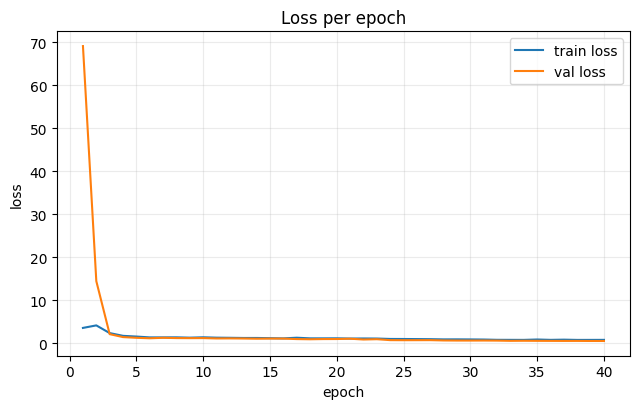

Epoch 40/40  train loss 0.8117 acc 0.7006 | val loss 0.5548 acc 0.8225  (best val acc 0.8225)
Best val acc: 0.8224852071005917 
Saved best checkpoint -> models\mbv2_dli14_best.pth


In [11]:
# === TRAIN + LIVE LOSS PLOT (per-epoch) ===
import torch, torch.nn as nn
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from pathlib import Path

# Reuse your globals if already set; otherwise fall back to sane defaults
device      = torch.device('cpu')
EPOCHS      = int(globals().get('EPOCHS', 40))
LR          = float(globals().get('LR', 0.05))
MODEL_DIR   = Path('model') if Path('model').exists() else Path('.')
OUT_DIR     = MODEL_DIR/'models'; OUT_DIR.mkdir(parents=True, exist_ok=True)
REPO        = str(globals().get('REPO', 'dli14')).lower()

# Use existing model/loaders/criterion/optimizer/scheduler if defined
model = globals().get('model', model).to(device)  # assumes you've already built MobileNetV2
loaders = globals().get('loaders', loaders)       # expects loaders['train'] and loaders['val']

criterion = globals().get('criterion', nn.CrossEntropyLoss())
optimizer = globals().get('optimizer', SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=4e-5))
scheduler = globals().get('scheduler', CosineAnnealingLR(optimizer, T_max=EPOCHS))

best_acc = 0.0
ckpt_path = OUT_DIR / f'mbv2_{REPO}_best.pth'

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

def run_epoch(dl, train=True):
    if train: model.train()
    else:     model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in tqdm(dl, leave=False):
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            loss = criterion(out, y)
            loss.backward(); optimizer.step()
        else:
            with torch.no_grad():
                out = model(x)
                loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum/max(1,total), correct/max(1,total)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(loaders['train'], train=True)
    va_loss, va_acc = run_epoch(loaders['val'],   train=False)
    scheduler.step()

    # record
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    # save best
    if va_acc >= best_acc:
        best_acc = va_acc
        torch.save({'model': model.state_dict(),
                    'classes': globals().get('CLASSES', [])}, ckpt_path)

    # ---- live plot: loss per epoch ----
    clear_output(wait=True)
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(6.5,4.2))
    plt.plot(epochs, history["train_loss"], label='train loss')
    plt.plot(epochs, history["val_loss"],   label='val loss')
    plt.title('Loss per epoch'); plt.xlabel('epoch'); plt.ylabel('loss')
    plt.legend(); plt.grid(True, alpha=.25); plt.tight_layout()
    display(plt.gcf())
    plt.close()

    # also print a concise line with metrics
    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}  "
          f"(best val acc {best_acc:.4f})")

# (optional) persist history for later plotting
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(OUT_DIR/'training_history.csv', index=False)
except Exception:
    pass

print("Best val acc:", best_acc, "\nSaved best checkpoint ->", ckpt_path)


## Graph Accuracy Plot: Training vs Validation 

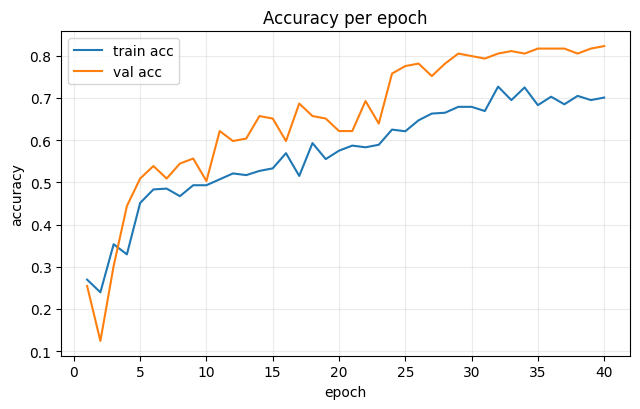

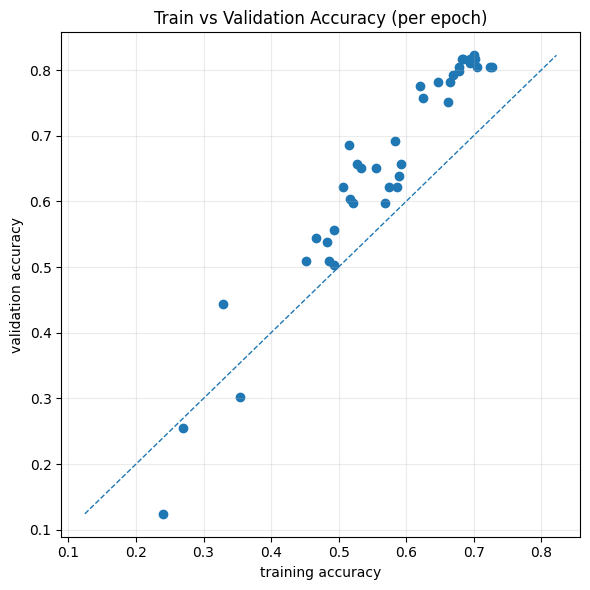

Avg gen gap (train - val): -0.0835   |   Max gap: 0.1153


In [ ]:
# === ACCURACY PLOTS: line (per epoch) + XY (train vs val) ===

import os, sys, subprocess
from pathlib import Path

# make sure matplotlib/pandas are available (installs once if missing)
try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas"])
    import matplotlib.pyplot as plt
    import pandas as pd

OUT_DIR = Path("model/models") if Path("model").exists() else Path("models")

# 1) get history (prefer in-memory; else load CSV saved by training cell)
hist = None
if "history" in globals() and isinstance(history, dict) and history.get("train_acc"):
    hist = history
elif (OUT_DIR/"training_history.csv").exists():
    df = pd.read_csv(OUT_DIR/"training_history.csv")
    cols = [c for c in ["train_acc","val_acc","train_loss","val_loss"] if c in df.columns]
    hist = {k: df[k].tolist() for k in cols}

if not hist or "train_acc" not in hist or "val_acc" not in hist:
    raise SystemExit("No accuracy history found. Run training (or save training_history.csv) first.")

epochs = range(1, len(hist["train_acc"])+1)

# 2) line chart: accuracy vs epoch
plt.figure(figsize=(6.5,4.2))
plt.plot(epochs, hist["train_acc"], label="train acc")
plt.plot(epochs, hist["val_acc"],   label="val acc")
plt.title("Accuracy per epoch")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# 3) XY scatter: train acc (X) vs val acc (Y) + y=x line
import numpy as np
ta = np.array(hist["train_acc"], dtype=float)
va = np.array(hist["val_acc"],   dtype=float)

plt.figure(figsize=(6.0,6.0))
plt.scatter(ta, va)
mn = float(min(ta.min(), va.min()))
mx = float(max(ta.max(), va.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)  # y = x reference
plt.xlabel("training accuracy")
plt.ylabel("validation accuracy")
plt.title("Train vs Validation Accuracy (per epoch)")
plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# (optional) quick text summary
gap = (ta - va)
print(f"Avg gen gap (train - val): {gap.mean():.4f}   |   Max gap: {gap.max():.4f}")


## 7) (Optional) Test set evaluation

In [12]:
from torch.utils.data import DataLoader
from torchvision import datasets
if (DST/'test').exists():
    test_ds = datasets.ImageFolder(DST/'test', transform=val_tfms)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred==y).sum().item(); total += x.size(0)
    print('Test accuracy:', correct/max(1,total))
else:
    print('No test split found — skipping.')

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test accuracy: 0.8414634146341463


## 8) Export TorchScript (.pt) and ONNX (.onnx)

In [15]:
model.eval()
dummy = torch.randn(1,3,INPUT_SIZE,INPUT_SIZE).to(device)

# TorchScript
ts = torch.jit.trace(model, dummy)
ts_path = MODEL_DIR/'models'/f'mobilenetv2_{REPO}.pt'
ts.save(str(ts_path))
print('Saved TorchScript ->', ts_path.resolve())

Saved TorchScript -> E:\Hedrian\BSIT 4B\CAPSTONE\2025-CP_Fishfresh\model\models\mobilenetv2_dli14.pt


---
### Notes & References
- **d-li14** repo: README usage and imagenet training flags (cosine LR, 0.05 LR, 4e-5 WD, 224px) — we mirror those defaults here.
- **tonylins** repo: canonical MobileNetV2 module; we import it directly and set `num_classes`.
- Normalization uses ImageNet mean/std; resize/crop = 224.
- You can raise `EPOCHS`, use label smoothing, or RandAugment to push accuracy if needed.


In [15]:
# 1) Use a super-short temp/cache path just for this notebook session
from pathlib import Path
import os
Path("C:/t").mkdir(parents=True, exist_ok=True)
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"] = r"C:\t"
os.environ["TEMP"] = r"C:\t"
os.environ["PIP_CACHE_DIR"] = r"C:\t\pip"

# 2) Install ONLY what's required for export: onnx (and onnxruntime if you want to test ONNX)
!pip install --no-cache-dir --only-binary=:all: onnx==1.15.0 onnxruntime==1.18.0

# (optional) If you still want onnxsim, try it after the two above succeed:
# !pip install --no-cache-dir onnxsim==0.4.36

ERROR: Could not find a version that satisfies the requirement onnx==1.15.0 (from versions: 1.16.0, 1.16.1, 1.16.2, 1.17.0, 1.18.0, 1.19.0)
ERROR: No matching distribution found for onnx==1.15.0


In [16]:
# keep super-short temp/cache paths for this session (avoids long-path issues)
from pathlib import Path
import os
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"] = r"C:\t"
os.environ["TEMP"] = r"C:\t"
os.environ["PIP_CACHE_DIR"] = r"C:\t\pip"

# install ONNX + ONNX Runtime (CPU) compatible with Python 3.12
!pip install --no-cache-dir onnx==1.19.0 onnxruntime==1.18.1


   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ----------------- ---------------------- 7.3/16.5 MB 45.1 MB/s eta 0:00:01
   ------------------------- -------------- 10.5/16.5 MB 28.4 MB/s eta 0:00:01
   -------------------------------- ------- 13.4/16.5 MB 22.1 MB/s eta 0:00:01
   ---------------------------------- ----- 14.2/16.5 MB 18.5 MB/s eta 0:00:01
   -------------------------------------- - 15.7/16.5 MB 15.7 MB/s eta 0:00:01
   ---------------------------------------- 16.5/16.5 MB 14.8 MB/s  0:00:01
   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   -------------------------- ------------- 3.7/5.6 MB 18.1 MB/s eta 0:00:01
   ----------------------------------- ---- 5.0/5.6 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 5.6/5.6 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/15.5 MB 7.2 MB/s eta 0:00:02
   -------- ----

  You can safely remove it manually.
  You can safely remove it manually.


In [18]:
# Short TEMP/CACHE paths for this session (prevents long-path issues on Windows)
from pathlib import Path
import os
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"] = r"C:\t"
os.environ["TEMP"] = r"C:\t"
os.environ["PIP_CACHE_DIR"] = r"C:\t\pip"

# Install ONNX->TF converter and TensorFlow (CPU)
!pip install --no-cache-dir onnx2tf tensorflow-cpu

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 2.1/331.9 MB 7.3 MB/s eta 0:00:45
   ---------------------------------------- 2.1/331.9 MB 7.3 MB/s eta 0:00:45
   ---------------------------------------- 2.1/331.9 MB 7.3 MB/s eta 0:00:45
   ---------------------------------------- 2.1/331.9 MB 7.3 MB/s eta 0:00:45
   ---------------------------------------- 2.1/331.9 MB 7.3 MB/s eta 0:00:45
   ---------------------------------------- 3.1/331.9 MB 2.1 MB/s eta 0:02:34
    --------------------------------------- 4.2/331.9 MB 2.5 MB/s eta 0:02:11
    --------------------------------------- 5.2/331.9 MB 2.7 MB/s eta 0:02:00
    --------------------------------------- 5.2/331.9 MB 2.7 MB/s eta 0:02:00
    --------------------------------------- 6.3/331.9 MB 2.9 MB/s eta 0:01:54
    --------------------------------------- 7.3/331.9 MB 3.0 MB/s eta 

In [19]:
# Convert ONNX to TensorFlow SavedModel
# NOTE: your ONNX input is NCHW (1,3,224,224). We tell onnx2tf to convert it to NHWC (1,224,224,3).
onnx_path = "model/models/mobilenetv2_dli14.onnx"
saved_model_dir = "model/models/mbv2_savedmodel"

!onnx2tf -i "{onnx_path}" --inputs-as-nchw "input" -o "{saved_model_dir}"
print("SavedModel at:", saved_model_dir)


SavedModel at: model/models/mbv2_savedmodel


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\.venv\Scripts\onnx2tf.exe\__main__.py", line 2, in <module>
  File "C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\.venv\Lib\site-packages\onnx2tf\__init__.py", line 1, in <module>
    from onnx2tf.onnx2tf import convert, main
  File "C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\.venv\Lib\site-packages\onnx2tf\onnx2tf.py", line 29, in <module>
    import tf_keras
ModuleNotFoundError: No module named 'tf_keras'


In [20]:
# keep short temp paths if you used them earlier
from pathlib import Path; import os
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"

# check your TF version (should show 2.20.x)
import tensorflow as tf; print("TF:", tf.__version__)

# install tf-keras with the SAME major.minor as TF (2.20.* here)
!pip install --no-cache-dir "tf-keras==2.20.*"

TF: 2.20.0
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 18.4 MB/s  0:00:00
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 3.1/331.9 MB 46.5 MB/s eta 0:00:08
    --------------------------------------- 4.2/331.9 MB 16.8 MB/s eta 0:00:20
    --------------------------------------- 5.2/331.9 MB 10.6 MB/s eta 0:00:31
   - -------------------------------------- 8.4/331.9 MB 11.1 MB/s eta 0:00:30
   - -------------------------------------- 9.4/331.9 MB 9.6 MB/s eta 0:00:34
   -- ------------------------------------- 16.8/331.9 MB 13.1 MB/s eta 0:00:25
   -- ------------------------------------- 17.6/331.9 MB 12.0 MB/s eta 0:00:27
   -- ------------------------------------- 19.1/331.9 MB 11.4 MB/s eta 0:00:28
   -- ------------------------------------- 20.4/331.9 MB 10.7 MB/s eta 0:00:30
   -- ------------------------------------- 22.0/331.9 MB 10.

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\LENOVO\\Desktop\\2025-CP_Fishfresh\\model\\.venv\\Lib\\site-packages\\tensorflow\\compiler\\mlir\\lite\\python\\_pywrap_converter_api.pyd'
Check the permissions.



In [21]:
# keep short temp paths if you used them earlier
from pathlib import Path, os
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"

# install tf-keras matching TF 2.20 without reinstalling TF itself
!pip install --no-cache-dir --no-deps "tf-keras==2.20.*"


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------ --------- 1.3/1.7 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 15.2 MB/s  0:00:00


In [25]:
from pathlib import Path
print("CWD:", Path.cwd())

# Try common locations
cands = [
    Path("model/models/mobilenetv2_dli14.onnx"),
    Path("models/mobilenetv2_dli14.onnx"),
]
for p in cands:
    print(p.resolve(), "exists:", p.exists())

# Fallback: search anywhere under the project
found = list(Path.cwd().rglob("mobilenetv2_*.onnx"))
print("\nSearch hits:")
for p in found: print(" -", p)


CWD: C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model
C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\model\models\mobilenetv2_dli14.onnx exists: False
C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\models\mobilenetv2_dli14.onnx exists: True

Search hits:
 - C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\models\mobilenetv2_dli14.onnx


In [27]:
from pathlib import Path
import os
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"] = r"C:\t"
os.environ["TEMP"] = r"C:\t"
os.environ["PIP_CACHE_DIR"] = r"C:\t\pip"

!pip install --no-cache-dir onnx-graphsurgeon


In [36]:
from pathlib import Path
import json

# try both common locations
json_candidates = [Path("models/classes.json"), Path("model/models/classes.json")]
txt_out = None
labels = None

for p in json_candidates:
    if p.exists():
        labels = json.loads(p.read_text())
        txt_out = p.with_name("classes.txt")
        txt_out.write_text("\n".join(labels))
        print("Wrote:", txt_out.resolve())
        break

# If classes.json wasn't found, rebuild labels from your train folders
if labels is None:
    train_roots = [Path("pytorch_imagenet/train"), Path("model/pytorch_imagenet/train")]
    root = next((r for r in train_roots if r.exists()), None)
    if root is None:
        raise SystemExit("Couldn't find classes.json or the train/ folder.")
    labels = sorted([d.name for d in root.iterdir() if d.is_dir()])
    out_dir = Path("models") if Path("models").exists() else Path("model/models")
    out_dir.mkdir(parents=True, exist_ok=True)
    txt_out = out_dir / "classes.txt"
    txt_out.write_text("\n".join(labels))
    print("Wrote:", txt_out.resolve(), "(rebuilt from train/ folders)")


Wrote: C:\Users\LENOVO\Desktop\2025-CP_Fishfresh\model\models\classes.txt
